In [2]:
# %%
import json
import sys
from collections import Counter, defaultdict
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

# Add CellViT repo to path
CELLVIT_REPO = Path(r"C:\Users\Andre\cursor_projects\CellViT-plus-plus")
sys.path.insert(0, str(CELLVIT_REPO))

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (16, 10)
plt.rcParams["font.size"] = 11

print(f"CellViT repo: {CELLVIT_REPO}")
print(f"Exists: {CELLVIT_REPO.exists()}")

# %%
# ============================================================
# CONFIGURATION - Update these paths
# ============================================================

# Path to directory containing CODA-classified GeoJSON files
GEOJSON_DIR = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\geojson_CODAclass")

# Output directory for results
OUT_DIR = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\cell_type_analysis")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Optional: Filter to specific slides (leave empty list to process all)
FILTER_SLIDE_IDS = []  # e.g., ["slide_001", "slide_002"]

# Optional: Exclude specific cell types from analysis
EXCLUDE_CELL_TYPES = ["Unassigned", "OutsideMask", "Background"]

print(f"\n{'='*70}")
print("CONFIGURATION")
print(f"{'='*70}")
print(f"GeoJSON directory: {GEOJSON_DIR}")
print(f"  Exists: {GEOJSON_DIR.exists()}")
print(f"Output directory: {OUT_DIR}")
print(f"  Exists: {OUT_DIR.exists()}")
print(f"Excluded cell types: {EXCLUDE_CELL_TYPES}")
print(f"{'='*70}\n")


CellViT repo: C:\Users\Andre\cursor_projects\CellViT-plus-plus
Exists: True

CONFIGURATION
GeoJSON directory: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\geojson_CODAclass
  Exists: True
Output directory: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\cell_type_analysis
  Exists: True
Excluded cell types: ['Unassigned', 'OutsideMask', 'Background']



In [3]:
## 2. Load Data
def extract_cell_types_from_geojson(geojson_path: Path) -> Dict[str, int]:
    """
    Extract cell type counts from a CODA-classified GeoJSON file.
    
    Args:
        geojson_path: Path to GeoJSON file
        
    Returns:
        Dictionary mapping cell type names to counts
    """
    try:
        with geojson_path.open("r", encoding="utf-8") as f:
            data = json.load(f)
    except (json.JSONDecodeError, FileNotFoundError) as e:
        print(f"[ERROR] Failed to load {geojson_path.name}: {e}")
        return {}
    
    # Support both bare list and FeatureCollection
    if isinstance(data, list):
        features = data
    else:
        features = data.get("features", [])
    
    cell_type_counts = Counter()
    
    for feat in features:
        # Extract classification from properties
        classification = feat.get("properties", {}).get("classification", {})
        cell_type = classification.get("name", "Unclassified")
        
        if cell_type:
            cell_type_counts[cell_type] += 1
    
    return dict(cell_type_counts)


def normalize_slide_stem(geojson_path: Path) -> str:
    """
    Normalize slide stem by removing CODA suffixes.
    
    Args:
        geojson_path: Path to GeoJSON file
        
    Returns:
        Normalized slide ID
    """
    stem = geojson_path.stem
    suffixes = ["__CODAclass", "_CODAclass", "-CODAclass", "_annotated", "__annotated"]
    
    for suffix in suffixes:
        if stem.endswith(suffix):
            return stem[:-len(suffix)]
    
    return stem

print("Helper functions defined ✓")

# %%
# Find all GeoJSON files
geojson_files = sorted(GEOJSON_DIR.glob("*.geojson"))

if not geojson_files:
    raise FileNotFoundError(f"No GeoJSON files found in {GEOJSON_DIR}")

print(f"Found {len(geojson_files)} GeoJSON files")

# Apply slide ID filter if specified
if FILTER_SLIDE_IDS:
    geojson_files = [
        gj for gj in geojson_files 
        if normalize_slide_stem(gj) in FILTER_SLIDE_IDS
    ]
    print(f"Filtered to {len(geojson_files)} slides based on FILTER_SLIDE_IDS")
else:
    print("Processing all slides (no filter applied)")

# %%
# Process all GeoJSON files
print("\nProcessing GeoJSON files...")
slide_data = []
all_cell_types = set()
processing_errors = []

for gj_path in tqdm(geojson_files, desc="Extracting cell types"):
    slide_id = normalize_slide_stem(gj_path)
    cell_counts = extract_cell_types_from_geojson(gj_path)
    
    if not cell_counts:
        processing_errors.append(gj_path.name)
        continue
    
    # Store results
    for cell_type, count in cell_counts.items():
        if cell_type not in EXCLUDE_CELL_TYPES:
            slide_data.append({
                "slide_id": slide_id,
                "cell_type": cell_type,
                "count": count,
                "geojson_file": gj_path.name
            })
            all_cell_types.add(cell_type)

# Convert to DataFrame
df = pd.DataFrame(slide_data)

if df.empty:
    raise ValueError("No cell data extracted. Check your GeoJSON files and EXCLUDE_CELL_TYPES setting.")

print(f"\n{'='*70}")
print("DATA LOADING COMPLETE")
print(f"{'='*70}")
print(f"Processed: {df['slide_id'].nunique()} slides")
print(f"Found: {len(all_cell_types)} unique cell types")
print(f"Total cells: {df['count'].sum():,}")
if processing_errors:
    print(f"\nWarning: {len(processing_errors)} files had no cells:")
    for err in processing_errors[:5]:
        print(f"  - {err}")
    if len(processing_errors) > 5:
        print(f"  ... and {len(processing_errors)-5} more")
print(f"{'='*70}\n")

# Display first few rows
print("Sample data:")
display(df.head(10))


Helper functions defined ✓
Found 24 GeoJSON files
Processing all slides (no filter applied)

Processing GeoJSON files...


Extracting cell types:   0%|          | 0/24 [00:00<?, ?it/s]


DATA LOADING COMPLETE
Processed: 23 slides
Found: 19 unique cell types
Total cells: 9,164,491

Sample data:


,slide_id,cell_type,count,geojson_file
0,monkey_fetus_40_0001,nontissue,758,monkey_fetus_40_0001.geojson
1,monkey_fetus_40_0001,heart,16,monkey_fetus_40_0001.geojson
2,monkey_fetus_40_0001,collagen,7661,monkey_fetus_40_0001.geojson
3,monkey_fetus_40_0001,brain,2113,monkey_fetus_40_0001.geojson
4,monkey_fetus_40_0001,bladder,408,monkey_fetus_40_0001.geojson
5,monkey_fetus_40_0001,skull,402,monkey_fetus_40_0001.geojson
6,monkey_fetus_40_0001,GI,288,monkey_fetus_40_0001.geojson
7,monkey_fetus_40_0001,mesokidney,4,monkey_fetus_40_0001.geojson
8,monkey_fetus_40_0051,nontissue,6820,monkey_fetus_40_0051.geojson
9,monkey_fetus_40_0051,collagen,62804,monkey_fetus_40_0051.geojson


In [4]:
# 3. Overall Statistics
# Calculate overall statistics
total_cells = df['count'].sum()
n_slides = df['slide_id'].nunique()
n_cell_types = df['cell_type'].nunique()

print("="*70)
print("OVERALL STATISTICS")
print("="*70)
print(f"Total slides: {n_slides}")
print(f"Total cells: {total_cells:,}")
print(f"Unique cell types: {n_cell_types}")
print(f"Average cells per slide: {total_cells / n_slides:.0f}")
print(f"Median cells per slide: {df.groupby('slide_id')['count'].sum().median():.0f}")
print("="*70)

# %%
# Cell type distribution (across all slides)
print("\n" + "="*70)
print("CELL TYPE DISTRIBUTION (All Slides Combined)")
print("="*70)

cell_type_totals = df.groupby("cell_type")["count"].sum().sort_values(ascending=False)

print(f"\n{'Cell Type':<35} {'Count':>12} {'Percentage':>12}")
print("-"*70)
for cell_type, count in cell_type_totals.items():
    pct = (count / total_cells) * 100
    print(f"{cell_type:<35} {count:>12,} {pct:>11.2f}%")

print("-"*70)
print(f"{'TOTAL':<35} {total_cells:>12,} {100.0:>11.2f}%")
print("="*70)

OVERALL STATISTICS
Total slides: 23
Total cells: 9,164,491
Unique cell types: 19
Average cells per slide: 398456
Median cells per slide: 439313

CELL TYPE DISTRIBUTION (All Slides Combined)

Cell Type                                  Count   Percentage
----------------------------------------------------------------------
collagen                               3,885,698       42.40%
brain                                  2,421,160       26.42%
liver                                  1,195,202       13.04%
bone                                     698,962        7.63%
nontissue                                256,029        2.79%
GI                                       177,078        1.93%
skull                                    138,377        1.51%
lungs                                     96,743        1.06%
heart                                     62,133        0.68%
eye                                       43,486        0.47%
mesokidney                                40,083        

In [5]:
# 4. Per-Slide Analysis
# Create pivot table: slides × cell types
print("Creating pivot table...")
pivot_df = df.pivot_table(
    index="slide_id",
    columns="cell_type",
    values="count",
    fill_value=0,
    aggfunc="sum"
)

# Add total column
pivot_df["TOTAL"] = pivot_df.sum(axis=1)

# Sort by total
pivot_df = pivot_df.sort_values("TOTAL", ascending=False)

print(f"Pivot table shape: {pivot_df.shape[0]} slides × {pivot_df.shape[1]-1} cell types")
print("\nTop 10 slides by total cell count:")
display(pivot_df.head(10))

# %%
# Per-slide detailed statistics
print("\n" + "="*70)
print("PER-SLIDE STATISTICS")
print("="*70)

slide_totals = df.groupby("slide_id")["count"].sum().sort_values(ascending=False)

print(f"\n{'Slide ID':<40} {'Total Cells':>15} {'Cell Types':>15}")
print("-"*70)

for i, slide_id in enumerate(slide_totals.index[:30], 1):  # Show top 30
    total = slide_totals[slide_id]
    n_types = df[df['slide_id'] == slide_id]['cell_type'].nunique()
    print(f"{i:2d}. {slide_id:<37} {total:>15,} {n_types:>15}")

if len(slide_totals) > 30:
    print(f"\n... and {len(slide_totals) - 30} more slides")

print("="*70)

# %%
# Statistical summary
print("\n" + "="*70)
print("SLIDE STATISTICS SUMMARY")
print("="*70)

slide_stats = slide_totals.describe()
print(f"\nCells per slide:")
print(f"  Min:     {slide_stats['min']:>10,.0f}")
print(f"  25%:     {slide_stats['25%']:>10,.0f}")
print(f"  Median:  {slide_stats['50%']:>10,.0f}")
print(f"  Mean:    {slide_stats['mean']:>10,.0f}")
print(f"  75%:     {slide_stats['75%']:>10,.0f}")
print(f"  Max:     {slide_stats['max']:>10,.0f}")
print(f"  Std:     {slide_stats['std']:>10,.0f}")

n_types_per_slide = df.groupby('slide_id')['cell_type'].nunique()
print(f"\nCell types per slide:")
print(f"  Min:     {n_types_per_slide.min():>10}")
print(f"  Median:  {n_types_per_slide.median():>10.0f}")
print(f"  Mean:    {n_types_per_slide.mean():>10.1f}")
print(f"  Max:     {n_types_per_slide.max():>10}")

print("="*70)

Creating pivot table...
Pivot table shape: 23 slides × 19 cell types

Top 10 slides by total cell count:


cell_type,GI,bladder,bone,brain,collagen,ear,eye,heart,kidney,liver,lungs,mesokidney,nontissue,pancreas,skull,spleen,spleen2,thymus,thyroid,TOTAL
slide_id,,,,,,,,,,,,,,,,,,,,
monkey_fetus_40_0551,34305,744,57977,271299,285833,1683,460,7990,111,62945,5863,2402,9133,11,7630,302,2098,10580,308,761674
monkey_fetus_40_0451,23214,205,58555,225824,311713,100,0,15545,5330,69392,19244,4769,6982,2564,8528,5497,216,1141,1492,760311
monkey_fetus_40_0501,22937,374,54370,257630,276789,636,8,14049,5730,47010,5465,3829,8455,2676,8630,6892,0,613,2163,718256
monkey_fetus_40_0351,12481,174,35445,310001,230652,3,0,9922,1,79895,13286,2972,6864,0,7317,0,3894,3422,1509,717838
monkey_fetus_40_0545,17924,1190,51094,269492,248888,890,272,6867,0,49269,4149,1829,7711,0,6648,2352,19,10292,215,679101
monkey_fetus_40_0301,8320,322,43141,247194,228462,1991,7957,1452,0,80905,0,0,9668,0,8489,0,115,3452,49,641517
monkey_fetus_40_0656,10618,854,46668,108809,249035,3720,170,1495,0,84571,16634,3065,7003,0,6580,6659,0,2881,16,548778
monkey_fetus_40_0712,9925,202,37043,97682,235104,1236,0,0,2932,107102,7498,1949,8618,58,6240,6201,0,807,14,522611
monkey_fetus_40_0767,4832,7,43717,96155,203315,588,7701,3,6522,121390,1255,3500,9329,4135,7092,3971,0,46,359,513917



PER-SLIDE STATISTICS

Slide ID                                     Total Cells      Cell Types
----------------------------------------------------------------------
 1. monkey_fetus_40_0551                          761,674              19
 2. monkey_fetus_40_0451                          760,311              18
 3. monkey_fetus_40_0501                          718,256              18
 4. monkey_fetus_40_0351                          717,838              16
 5. monkey_fetus_40_0545                          679,101              17
 6. monkey_fetus_40_0301                          641,517              14
 7. monkey_fetus_40_0656                          548,778              16
 8. monkey_fetus_40_0712                          522,611              16
 9. monkey_fetus_40_0767                          513,917              18
10. monkey_fetus_40_0601                          480,825              18
11. monkey_fetus_40_0251                          445,965              13
12. monkey_fetus_40

Generating overall cell type distribution chart...
[SAVED] \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\cell_type_analysis\01_cell_type_distribution_overall.png


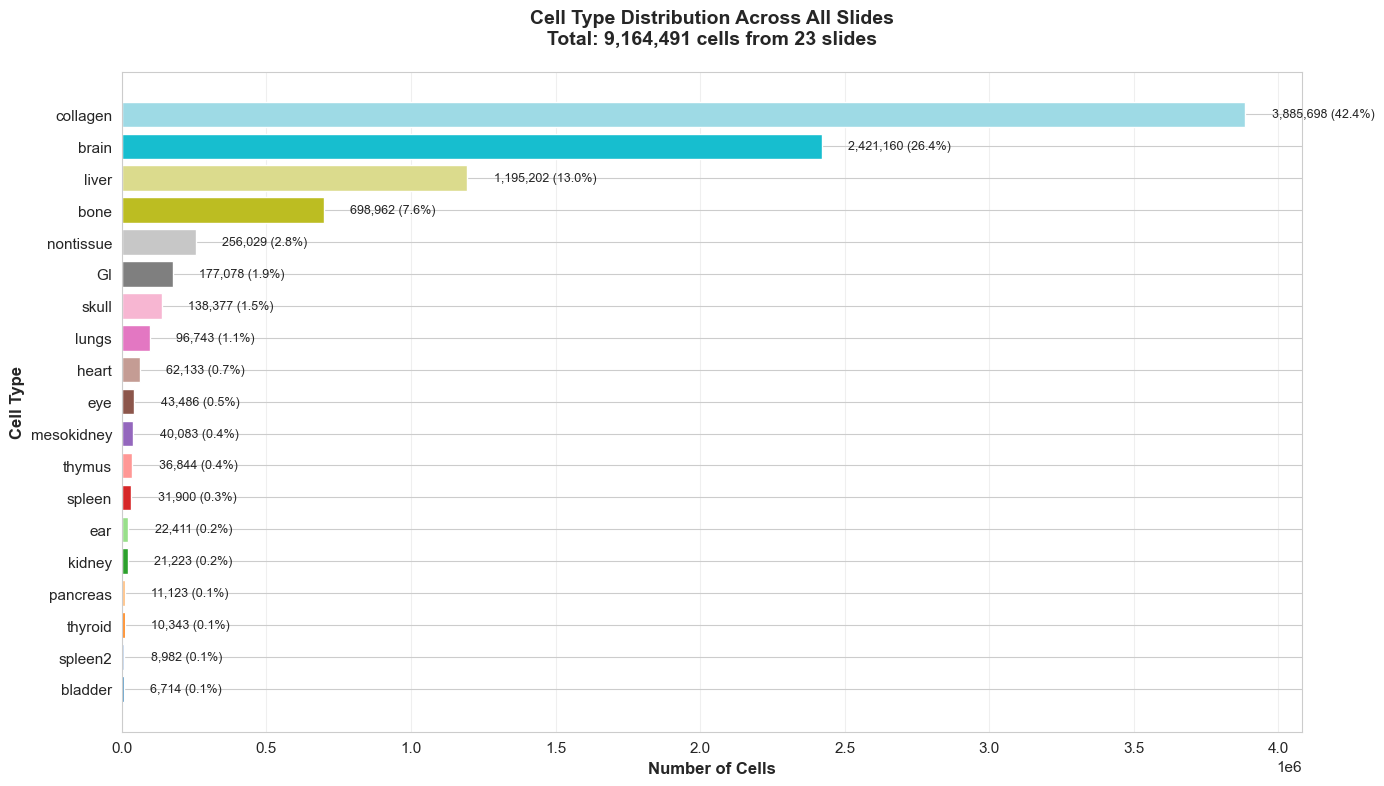

In [6]:
# 5. Cell Type Distribution Visualization (Overall Bar Chart)

# %%
# Overall cell type distribution (bar plot)
print("Generating overall cell type distribution chart...")

fig, ax = plt.subplots(figsize=(14, 8))

cell_type_totals_sorted = cell_type_totals.sort_values(ascending=True)
colors = plt.cm.tab20(np.linspace(0, 1, len(cell_type_totals_sorted)))

bars = ax.barh(range(len(cell_type_totals_sorted)), cell_type_totals_sorted.values, color=colors)
ax.set_yticks(range(len(cell_type_totals_sorted)))
ax.set_yticklabels(cell_type_totals_sorted.index)

ax.set_xlabel("Number of Cells", fontsize=12, fontweight="bold")
ax.set_ylabel("Cell Type", fontsize=12, fontweight="bold")
ax.set_title(
    f"Cell Type Distribution Across All Slides\n"
    f"Total: {total_cells:,} cells from {n_slides} slides",
    fontsize=14,
    fontweight="bold",
    pad=20
)
ax.grid(axis="x", alpha=0.3)

# Add count labels
for i, (cell_type, count) in enumerate(cell_type_totals_sorted.items()):
    pct = (count / total_cells) * 100
    ax.text(count + total_cells*0.01, i, f"{count:,} ({pct:.1f}%)", 
            va='center', fontsize=9)

plt.tight_layout()
output_path = OUT_DIR / "01_cell_type_distribution_overall.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"[SAVED] {output_path}")
plt.show()

Generating per-slide stacked bar chart...
[SAVED] \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\cell_type_analysis\02_cell_type_distribution_per_slide.png


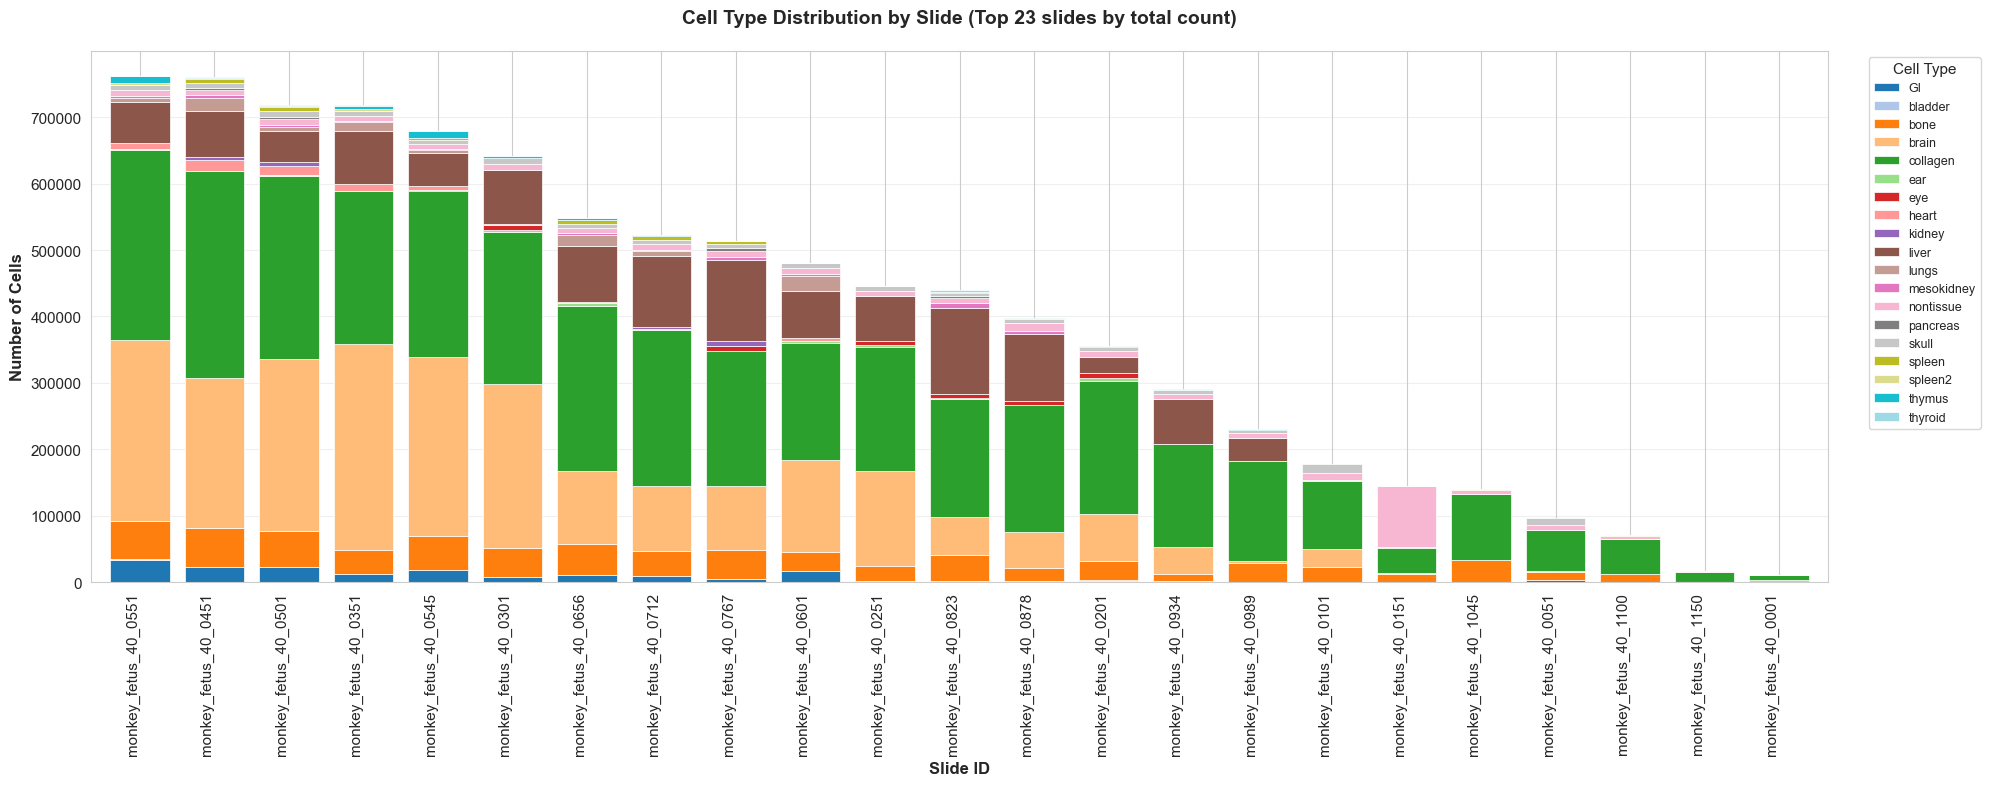

In [7]:
# 6. Per-Slide Distribution Visualization (Stacked Bar Chart)

# %%
# Cell type distribution per slide (stacked bar chart)
print("Generating per-slide stacked bar chart...")

fig, ax = plt.subplots(figsize=(20, 8))

# Select top N slides by total cell count
top_n_slides = min(40, len(pivot_df))
pivot_plot = pivot_df.drop(columns=["TOTAL"]).head(top_n_slides)

pivot_plot.plot(kind="bar", stacked=True, ax=ax, 
                colormap="tab20", width=0.8, edgecolor="white", linewidth=0.5)

ax.set_xlabel("Slide ID", fontsize=12, fontweight="bold")
ax.set_ylabel("Number of Cells", fontsize=12, fontweight="bold")
ax.set_title(
    f"Cell Type Distribution by Slide (Top {top_n_slides} slides by total count)",
    fontsize=14,
    fontweight="bold",
    pad=20
)
ax.legend(title="Cell Type", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=90, ha="right")

plt.tight_layout()
output_path = OUT_DIR / "02_cell_type_distribution_per_slide.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"[SAVED] {output_path}")
plt.show()

In [10]:
# 10. Export Results

# %%
# 1. Export detailed cell counts per slide (pivot table)
print("\nExporting results...")

output_csv = OUT_DIR / "cell_counts_per_slide.csv"
pivot_df.to_csv(output_csv)
print(f"[SAVED] {output_csv}")

# %%
# 2. Export summary statistics per cell type
summary_stats = pd.DataFrame({
    "cell_type": cell_type_totals.index,
    "total_count": cell_type_totals.values,
    "percentage": (cell_type_totals.values / total_cells * 100).round(2),
    "n_slides_present": [
        (pivot_df.drop(columns=["TOTAL"])[ct] > 0).sum() 
        for ct in cell_type_totals.index
    ],
    "mean_per_slide": [
        pivot_df.drop(columns=["TOTAL"])[ct][pivot_df[ct] > 0].mean().round(1) 
        for ct in cell_type_totals.index
    ],
    "median_per_slide": [
        pivot_df.drop(columns=["TOTAL"])[ct][pivot_df[ct] > 0].median() 
        for ct in cell_type_totals.index
    ],
    "std_per_slide": [
        pivot_df.drop(columns=["TOTAL"])[ct][pivot_df[ct] > 0].std().round(1) 
        for ct in cell_type_totals.index
    ],
    "min_per_slide": [
        pivot_df.drop(columns=["TOTAL"])[ct][pivot_df[ct] > 0].min() 
        for ct in cell_type_totals.index
    ],
    "max_per_slide": [
        pivot_df.drop(columns=["TOTAL"])[ct][pivot_df[ct] > 0].max() 
        for ct in cell_type_totals.index
    ]
})

summary_csv = OUT_DIR / "cell_type_summary.csv"
summary_stats.to_csv(summary_csv, index=False)
print(f"[SAVED] {summary_csv}")

print("\nCell type summary:")
display(summary_stats)

# %%
# 3. Export per-slide totals
slide_summary = pd.DataFrame({
    "slide_id": slide_totals.index,
    "total_cells": slide_totals.values,
    "n_cell_types": [
        df[df['slide_id'] == sid]['cell_type'].nunique() 
        for sid in slide_totals.index
    ]
})

slide_summary_csv = OUT_DIR / "slide_summary.csv"
slide_summary.to_csv(slide_summary_csv, index=False)
print(f"[SAVED] {slide_summary_csv}")

print("\nSlide summary (first 10):")
display(slide_summary.head(10))

# %%
# 4. Export original DataFrame (long format)
detailed_csv = OUT_DIR / "cell_counts_detailed.csv"
df.to_csv(detailed_csv, index=False)
print(f"[SAVED] {detailed_csv}")

# %%
# 5. Create a summary report text file
report_path = OUT_DIR / "analysis_report.txt"

with report_path.open("w", encoding="utf-8") as f:
    f.write("="*70 + "\n")
    f.write("CODA CELL TYPE DISTRIBUTION ANALYSIS REPORT\n")
    f.write("="*70 + "\n\n")
    
    f.write(f"Analysis Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"GeoJSON Directory: {GEOJSON_DIR}\n")
    f.write(f"Output Directory: {OUT_DIR}\n\n")
    
    f.write("="*70 + "\n")
    f.write("OVERALL STATISTICS\n")
    f.write("="*70 + "\n")
    f.write(f"Total slides processed: {n_slides}\n")
    f.write(f"Total cells analyzed: {total_cells:,}\n")
    f.write(f"Unique cell types: {n_cell_types}\n")
    f.write(f"Average cells per slide: {total_cells / n_slides:.0f}\n")
    f.write(f"Median cells per slide: {slide_totals.median():.0f}\n\n")
    
    f.write("="*70 + "\n")
    f.write("CELL TYPE DISTRIBUTION\n")
    f.write("="*70 + "\n")
    f.write(f"{'Cell Type':<35} {'Count':>12} {'Percentage':>12}\n")
    f.write("-"*70 + "\n")
    for cell_type, count in cell_type_totals.items():
        pct = (count / total_cells) * 100
        f.write(f"{cell_type:<35} {count:>12,} {pct:>11.2f}%\n")
    f.write("-"*70 + "\n")
    f.write(f"{'TOTAL':<35} {total_cells:>12,} {100.0:>11.2f}%\n\n")
    
    f.write("="*70 + "\n")
    f.write("TOP 20 SLIDES BY CELL COUNT\n")
    f.write("="*70 + "\n")
    f.write(f"{'Rank':<6} {'Slide ID':<40} {'Total Cells':>15}\n")
    f.write("-"*70 + "\n")
    for i, (slide_id, count) in enumerate(slide_totals.head(20).items(), 1):
        f.write(f"{i:<6} {slide_id:<40} {count:>15,}\n")
    
    f.write("\n" + "="*70 + "\n")
    f.write("OUTPUT FILES\n")
    f.write("="*70 + "\n")
    f.write("CSV Files:\n")
    f.write("  - cell_counts_per_slide.csv (pivot table)\n")
    f.write("  - cell_type_summary.csv (aggregated statistics)\n")
    f.write("  - slide_summary.csv (per-slide totals)\n")
    f.write("  - cell_counts_detailed.csv (raw data in long format)\n\n")
    f.write("Visualizations:\n")
    f.write("  - 01_cell_type_distribution_overall.png\n")
    f.write("  - 02_cell_type_distribution_per_slide.png\n")
    f.write("  - 03_cell_type_heatmap.png\n")
    f.write("  - 04_cell_type_heatmap_log.png\n")
    f.write("  - 05_cell_type_boxplot.png\n")
    f.write("  - 06_cell_type_pie_chart.png\n")
    f.write("="*70 + "\n")

print(f"[SAVED] {report_path}")

# %% [markdown]
# ## Summary

# %%
print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)
print(f"\nProcessed: {n_slides} slides")
print(f"Total cells: {total_cells:,}")
print(f"Cell types: {n_cell_types}")

print(f"\nTop 5 cell types:")
for i, (ct, count) in enumerate(cell_type_totals.head(5).items(), 1):
    pct = (count / total_cells) * 100
    print(f"  {i}. {ct}: {count:,} ({pct:.2f}%)")

print(f"\nAll outputs saved to: {OUT_DIR}")
print("\nGenerated files:")
print("  CSV Files:")
print("    - cell_counts_per_slide.csv")
print("    - cell_type_summary.csv")
print("    - slide_summary.csv")
print("    - cell_counts_detailed.csv")
print("  Visualizations:")
print("    - 01_cell_type_distribution_overall.png")
print("    - 02_cell_type_distribution_per_slide.png")
print("    - 03_cell_type_heatmap.png")
print("    - 04_cell_type_heatmap_log.png")
print("    - 05_cell_type_boxplot.png")
print("    - 06_cell_type_pie_chart.png")
print("  Report:")
print("    - analysis_report.txt")
print("="*70)



Exporting results...
[SAVED] \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\cell_type_analysis\cell_counts_per_slide.csv
[SAVED] \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\cell_type_analysis\cell_type_summary.csv

Cell type summary:


,cell_type,total_count,percentage,n_slides_present,mean_per_slide,median_per_slide,std_per_slide,min_per_slide,max_per_slide
0,collagen,3885698,42.40,23,168943.4,186503.0,89265.9,7661,311713
1,brain,2421160,26.42,23,105267.8,70681.0,106513.3,74,310001
2,liver,1195202,13.04,19,62905.4,67543.0,38754.3,2,128970
3,bone,698962,7.63,22,31771.0,31248.5,16619.2,12,58555
4,nontissue,256029,2.79,23,11131.7,7957.0,17728.8,758,91636
5,GI,177078,1.93,23,7699.0,2606.0,9455.6,77,34305
6,skull,138377,1.51,23,6016.4,6648.0,3426.4,3,12396
7,lungs,96743,1.06,11,8794.8,5863.0,8101.7,8,23333
8,heart,62133,0.68,19,3270.2,18.0,5118.4,1,15545
9,eye,43486,0.47,14,3106.1,403.5,3558.9,1,7957


[SAVED] \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\cell_type_analysis\slide_summary.csv

Slide summary (first 10):


,slide_id,total_cells,n_cell_types
0,monkey_fetus_40_0551,761674,19
1,monkey_fetus_40_0451,760311,18
2,monkey_fetus_40_0501,718256,18
3,monkey_fetus_40_0351,717838,16
4,monkey_fetus_40_0545,679101,17
5,monkey_fetus_40_0301,641517,14
6,monkey_fetus_40_0656,548778,16
7,monkey_fetus_40_0712,522611,16
8,monkey_fetus_40_0767,513917,18
9,monkey_fetus_40_0601,480825,18


[SAVED] \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\cell_type_analysis\cell_counts_detailed.csv
[SAVED] \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\cell_type_analysis\analysis_report.txt

ANALYSIS COMPLETE

Processed: 23 slides
Total cells: 9,164,491
Cell types: 19

Top 5 cell types:
  1. collagen: 3,885,698 (42.40%)
  2. brain: 2,421,160 (26.42%)
  3. liver: 1,195,202 (13.04%)
  4. bone: 698,962 (7.63%)
  5. nontissue: 256,029 (2.79%)

All outputs saved to: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\cell_type_analysis

Generated files:
  CSV Files:
    - cell_counts_per_slide.csv
    - cell_type_summary.csv
    - slide_summary.csv
    - cell_counts_detailed.csv
  Visualizations:
    - 01_cell_type_distribution_overall.png
    - 02_cell_type_distribution_per_slide.png
    - 03_cell_type_heatmap.png
    - 04_cell_type_heatmap_log.png
    - 05_cell_type_boxplot.png
    - 06_cell_type